In [25]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("data/imdb_dataset.csv")

In [4]:
data.shape

(50000, 2)

In [5]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:
data['sentiment'] = data['sentiment'].map({
    'positive': 1,
    'negative': 0
})
print(data['sentiment'])

0        1
1        1
2        1
3        0
4        1
        ..
49995    1
49996    0
49997    0
49998    0
49999    0
Name: sentiment, Length: 50000, dtype: int64


In [7]:
x = data['review'].values
y = data['sentiment'].values

In [8]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [9]:
from tensorflow.keras.preprocessing.text import Tokenizer
vocab_size = 10000
max_length = 200

tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(x_train)

In [10]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
x_train = tokenizer.texts_to_sequences(x_train)
x_test = tokenizer.texts_to_sequences(x_test)

x_train = pad_sequences(x_train, maxlen=max_length, padding='post')
x_test = pad_sequences(x_test, maxlen=max_length, padding='post')

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model = Sequential([
    Embedding(vocab_size, output_dim=128),
    LSTM(128),
    Dense(1, activation='sigmoid')
])

In [12]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [13]:
history = model.fit(x_train, y_train, epochs=5)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 188s 148ms/step - accuracy: 0.6314 - loss: 0.6073
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 196s 143ms/step - accuracy: 0.8749 - loss: 0.3165
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 179s 143ms/step - accuracy: 0.9245 - loss: 0.2023
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 178s 143ms/step - accuracy: 0.9484 - loss: 0.1469
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 199s 140ms/step - accuracy: 0.9649 - loss: 0.1035


In [81]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.8941 - loss: 0.3287
Test Loss: 0.3287
Test Accuracy: 0.8941


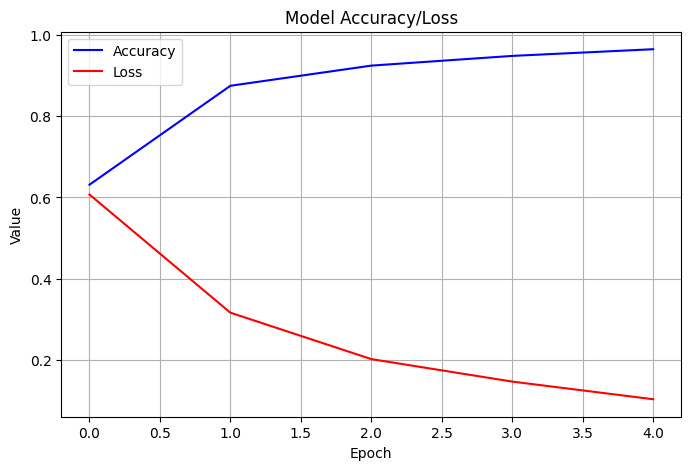

In [69]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], color='blue', label='Accuracy')
plt.plot(history.history['loss'], color='red', label='Loss')
plt.title("Model Accuracy/Loss")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.grid(True)


In [70]:
y_pred = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step


In [71]:
from sklearn.metrics import confusion_matrix

y_pred = (y_pred_prob >= 0.5).astype(int).reshape(-1)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[4480  481]
 [ 578 4461]]
              precision    recall  f1-score   support

           0       0.89      0.90      0.89      4961
           1       0.90      0.89      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



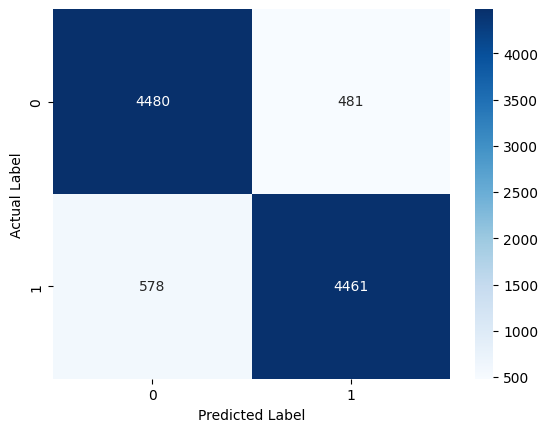

In [74]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

In [75]:
def predict(review):
    sequence = tokenizer.texts_to_sequences([review])
    padded_sequence = pad_sequences(sequence, maxlen=200, padding='post')
    prob = model.predict(padded_sequence)[0][0]
    if prob >= 0.5:
        label = "Positive"
    else:
        label = "Negative"
    return label, float(prob)

In [76]:
sample_review1 = "This is not the best movie ever made, but it’s worth watching."
label, confidence = predict(sample_review1)
print(f"Prediction: {label} (Confidence: {confidence:.2f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Prediction: Positive (Confidence: 0.98)


In [77]:
sample_review2 = "The movie is not bad, but it’s not good either.."
label, confidence = predict(sample_review2)
print(f"Prediction: {label} (Confidence: {confidence:.2f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Prediction: Negative (Confidence: 0.13)


In [78]:
sample_review3 = "Despite its flaws, the movie is genuinely enjoyable."
label, confidence = predict(sample_review3)
print(f"Prediction: {label} (Confidence: {confidence:.2f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Prediction: Positive (Confidence: 0.96)


In [79]:
sample_review4 = "If boredom had an Oscar category, this movie would definitely win."
label, confidence = predict(sample_review4)
print(f"Prediction: {label} (Confidence: {confidence:.2f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Prediction: Negative (Confidence: 0.15)
